In [1]:
import gc
gc.collect()

import os
import re
import glob
import warnings
from collections import defaultdict
from functools import lru_cache  # MOD1

import numpy as np
import uproot
import torch

import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
from mpl_toolkits.mplot3d.art3d import Line3DCollection  # MOD1
from matplotlib.ticker import FuncFormatter

In [2]:
!ls data/

MuonSegmentDump_JPsi_pu0_part1.root    MuonSegmentDump_R3SimHits_part16.root
MuonSegmentDump_JPsi_pu0_part2.root    MuonSegmentDump_R3SimHits_part17.root
MuonSegmentDump_JPsi_pu0_part3.root    MuonSegmentDump_R3SimHits_part2.root
MuonSegmentDump_R3SimHits_part1.root   MuonSegmentDump_R3SimHits_part3.root
MuonSegmentDump_R3SimHits_part10.root  MuonSegmentDump_R3SimHits_part4.root
MuonSegmentDump_R3SimHits_part11.root  MuonSegmentDump_R3SimHits_part5.root
MuonSegmentDump_R3SimHits_part12.root  MuonSegmentDump_R3SimHits_part6.root
MuonSegmentDump_R3SimHits_part13.root  MuonSegmentDump_R3SimHits_part7.root
MuonSegmentDump_R3SimHits_part14.root  MuonSegmentDump_R3SimHits_part8.root
MuonSegmentDump_R3SimHits_part15.root  MuonSegmentDump_R3SimHits_part9.root


In [5]:
input_file  = "data/MuonSegmentDump_R3SimHits_part17.root"
mc_labels = True

In [6]:
# open root file with uproot but also have a look on at the tree structure
root_file = uproot.open(input_file)

In [7]:
# tree is MuonSegmentDump. Print now available branches
print(root_file["MuonSegmentDump;1"].keys())

['CommonEventHash[2]/l', 'bucket_chamberIndex', 'bucket_layers', 'bucket_sector', 'bucket_segments', 'bucket_spacePoints', 'segmentDirectionX', 'segmentDirectionY', 'segmentDirectionZ', 'segmentEta', 'segmentHasTruth', 'segmentPhi', 'segmentPositionX', 'segmentPositionY', 'segmentPositionZ', 'segmentTruthEta', 'segmentTruthPDGId', 'segmentTruthPart', 'segmentTruthPhi', 'segmentTruthPt', 'segment_chiSquared', 'segment_numberDoF']


In [8]:
REQUIRED_SEGMENT_BRANCHES = [
    "segmentDirectionX",
    "segmentDirectionY",
    "segmentDirectionZ",
    "segmentPositionX",
    "segmentPositionY",
    "segmentPositionZ",
    "CommonEventHash",
    "segmentHasTruth",
    "segmentTruthPart",
    # NEW bucket info (assumed per segment entry)
    "bucket_chamberIndex",
    "bucket_layers",
    "bucket_sector",
    "bucket_segments",
]


In [9]:
def _normalize_keys(keys):
    """Remove uproot's '[...]/D' etc. decorations."""
    return {re.sub(r"\[.*\]/[A-Za-z]$", "", k): k for k in keys}

def _open_segment_tree_auto(root_file: str, preferred_tree_names=("MuonSegmentDump",)):
    """
    Auto-discover the MuonSegmentDump TTree (or allow 'file.root:Tree').
    """
    # Allow "file.root:Tree"
    if ":" in root_file and not root_file.strip().endswith(":"):
        obj = uproot.open(root_file)
        try:
            _ = obj.num_entries
        except Exception as e:
            raise ValueError(f"Object selected by '{root_file}' is not a TTree.") from e
        return obj

    f = uproot.open(root_file)
    trees = []
    for name, obj in f.items():
        short = name.split(";")[0]
        try:
            _ = obj.num_entries
            trees.append((short, obj))
        except Exception:
            continue
    if not trees:
        raise ValueError(f"No TTrees found in '{root_file}'.")

    def has_required(tobj):
        clean = _normalize_keys(list(tobj.keys()))
        return all(b in clean for b in REQUIRED_SEGMENT_BRANCHES)

    for pref in preferred_tree_names:
        for tname, tobj in trees:
            if tname == pref and has_required(tobj):
                return tobj
    for tname, tobj in trees:
        if has_required(tobj):
            return tobj

    raise ValueError("Could not find a TTree with required segment branches.")

def _to_1d_float(a):
    """
    Convert a 1D array-like (possibly dtype=object with small ndarrays)
    into a plain 1D float64 NumPy array.
    Takes the first element if entries are arrays/vectors.
    """
    a = np.asarray(a, dtype=object)
    return np.array([float(np.ravel(x)[0]) for x in a], dtype=np.float64)

In [10]:
def _read_segment_tree(root_file: str):
    """
    Read required segment branches and build mapping
    event-hash -> list of entry indices.
    """
    tree = _open_segment_tree_auto(root_file, preferred_tree_names=("MuonSegmentDump",))
    clean = _normalize_keys(list(tree.keys()))
    missing = [k for k in REQUIRED_SEGMENT_BRANCHES if k not in clean]
    if missing:
        raise ValueError(f"Missing segment branches: {missing}")

    arrays = tree.arrays([clean[k] for k in REQUIRED_SEGMENT_BRANCHES], library="np")
    td = {k: arrays[clean[k]] for k in REQUIRED_SEGMENT_BRANCHES}

    # ---------- FIXED PART (flatten CommonEventHash) ----------
    evh_arr = td["CommonEventHash"]

    # Case 1: regular 2D array with shape (N, 1)
    if isinstance(evh_arr, np.ndarray) and evh_arr.ndim == 2 and evh_arr.shape[1] == 1:
        event_hashes = evh_arr[:, 0].astype(np.int64)

    else:
        # General case: sequence of scalars or 1-element arrays/objects
        # e.g. dtype=object, each entry something like array([123456789], dtype='>i8')
        event_hashes = np.asarray(
            [int(np.ravel(x)[0]) for x in evh_arr],
            dtype=np.int64
        )
    # ---------------------------------------------------------

    # Unique hashes in order of first appearance
    seen = set()
    unique_hashes = []
    for h in event_hashes:
        if h not in seen:
            seen.add(h)
            unique_hashes.append(h)
    unique_hashes = np.array(unique_hashes, dtype=np.int64)

    # Map event_hash -> list of indices
    ev_to_idx = defaultdict(list)
    for i, h in enumerate(event_hashes):
        ev_to_idx[int(h)].append(i)

    return td, ev_to_idx, unique_hashes

In [11]:
def build_segment_event_from_root(root_file: str, event_number: int):
    """
    Return (pos, dir, event_hash, has_truth, truth_part) for a given event_number.

    pos: (N, 3) array   [mm]
    dir: (N, 3) array
    has_truth: (N,) array of 0/1
    truth_part: (N,) array of ints (or -1 for no-truth)
    """
    td, ev_to_idx, uniq = _read_segment_tree(root_file)

    if event_number < 0 or event_number >= len(uniq):
        raise IndexError(f"event_number {event_number} out of range (0..{len(uniq)-1}).")

    evh = int(uniq[event_number])
    idxs = np.asarray(ev_to_idx[evh], dtype=np.int64)
    if idxs.size == 0:
        raise RuntimeError(f"No segments found for event hash={evh}.")

    px_list, py_list, pz_list = [], [], []
    dx_list, dy_list, dz_list = [], [], []
    has_truth_list = []
    truth_part_list = []

    def first_or_none(x):
        a = np.ravel(x)
        if a.size == 0:
            return None
        return float(a[0])

    for i in idxs:
        px = first_or_none(td["segmentPositionX"][i])
        py = first_or_none(td["segmentPositionY"][i])
        pz = first_or_none(td["segmentPositionZ"][i])

        dx = first_or_none(td["segmentDirectionX"][i])
        dy = first_or_none(td["segmentDirectionY"][i])
        dz = first_or_none(td["segmentDirectionZ"][i])

        # Skip if any component missing
        if None in (px, py, pz, dx, dy, dz):
            continue

        px_list.append(px)
        py_list.append(py)
        pz_list.append(pz)
        dx_list.append(dx)
        dy_list.append(dy)
        dz_list.append(dz)

        # Truth information (scalar)
        has_truth_val = int(np.ravel(td["segmentHasTruth"][i])[0])
        has_truth_list.append(has_truth_val)

        if has_truth_val == 0:
            truth_part_list.append(-1)   # sentinel for "no truth"
        else:
            truth_part_list.append(int(np.ravel(td["segmentTruthPart"][i])[0]))

    if len(px_list) == 0:
        raise RuntimeError(f"All segments for event hash={evh} are empty.")

    pos  = np.stack([px_list, py_list, pz_list], axis=1)
    dire = np.stack([dx_list, dy_list, dz_list], axis=1)
    has_truth = np.array(has_truth_list, dtype=int)
    truth_part = np.array(truth_part_list, dtype=int)

    return pos, dire, evh, has_truth, truth_part


In [12]:
def _add_atlas_labels(fig, ax, atlas_label="Internal", llabel=r"$Z\\rightarrow \\mu\\mu$"):
    """
    Draw ATLAS-style labels anchored to the axes' bbox (figure coords),
    with only 'ATLAS' bold and the rest regular — no LaTeX required.
    """
    box = ax.get_position()  # Bbox in figure coords (0..1)
    x0, y0, w, h = box.x0, box.y0, box.width, box.height
    x = x0 + 0.02 * w
    y1 = y0 + 0.95 * h
    y2 = y0 + 0.90 * h

    # 1) Bold "ATLAS"
    t1 = fig.text(x, y1, "ATLAS", fontsize=16, fontweight="bold", style="italic", ha="left", va="top")

    # 2) Measure its width in figure units to place the regular label after it
    fig.canvas.draw()  # ensure renderer exists
    renderer = fig.canvas.get_renderer()
    bb = t1.get_window_extent(renderer=renderer)
    dx = bb.width / fig.bbox.width  # pixels -> figure fraction

    # 3) Regular atlas_label right after "ATLAS"
    fig.text(x + dx - 0.001 , y1, f" {atlas_label}", fontsize=16,
             ha="left", va="top")

    # 4) The physics channel label (italic)
    fig.text(x, y2, llabel, fontsize=14, style="italic",
             ha="left", va="top")


In [13]:
def plot_segment_event_3d(
    pos_mm: np.ndarray,
    dir_vec: np.ndarray,
    event_number: int,
    event_hash: int,
    has_truth: np.ndarray,
    truth_part: np.ndarray,
    arrow_length_frac: float = 0.05,
    atlas_label: str = "Simulation Internal",
    llabel: str = r"$Z\rightarrow \mu\mu$",
    external_zlabel: bool = True,
    external_zlabel_dx: float = 0.02,   # figure-fraction offset to the RIGHT of axes bbox
):
    """
    Plot each segment with arrow + truth-coloring.

    Axis mapping:
        plot_x = Z (horizontal, longest)
        plot_y = X (depth)
        plot_z = Y (vertical)
    """
    pos_mm = np.asarray(pos_mm, dtype=float)
    dir_vec = np.asarray(dir_vec, dtype=float)
    has_truth = np.asarray(has_truth, dtype=int)
    truth_part = np.asarray(truth_part, dtype=int)

    # Convert mm → m
    pos = pos_mm / 1000.0
    X = pos[:, 0]
    Y = pos[:, 1]
    Z = pos[:, 2]

    # Axis remapping (matplotlib axes -> detector coordinates)
    plot_x = Z  # X axis shows Z
    plot_y = X  # Y axis shows X
    plot_z = Y  # Z axis shows Y

    # Directions, normalize
    norm = np.linalg.norm(dir_vec, axis=1)
    norm[norm == 0] = 1.0
    dx, dy, dz = dir_vec[:, 0] / norm, dir_vec[:, 1] / norm, dir_vec[:, 2] / norm

    # Direction remapping
    arrow_u = dz   # along plot_x (Z direction)
    arrow_v = dx   # along plot_y (X direction)
    arrow_w = dy   # along plot_z (Y direction)

    # Spans and arrow size
    span_x = 50
    span_y = 24
    span_z = 24
    span = max(span_x, span_y, span_z)
    arrow_length = arrow_length_frac * (span if span > 0 else 1.0)

    # ---------- COLORS ----------
    colors = np.zeros((len(plot_x), 3))
    gray = np.array([0.6, 0.6, 0.6])

    truth_mask = has_truth != 0
    colors[~truth_mask] = gray

    unique_parts = np.unique(truth_part[truth_mask])

    if len(unique_parts) > 0:
        default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        # map particles → C1, C2, C3, ...
        part_to_color = {
            p: default_colors[(i + 1) % len(default_colors)]
            for i, p in enumerate(unique_parts)
        }

        for i in range(len(plot_x)):
            if truth_mask[i]:
                colors[i] = mpl.colors.to_rgb(part_to_color[truth_part[i]])
                
                
    # ---------- LEGEND ----------
    legend_handles = []
    from matplotlib.lines import Line2D

    # Background (no truth)
    legend_handles.append(
        Line2D([0], [0], marker='o', linestyle='',
               color=gray, markersize=8, label="background")
    )

    # Truth particles, using the same C1, C2, C3... mapping
    for p in unique_parts:
        c = part_to_color[p]
        legend_handles.append(
            Line2D([0], [0], marker='o', linestyle='',
                   color=c, markersize=8, label=f"truth μ {p}")
        )


    # ---------- PLOT ----------
    fig = plt.figure(figsize=(20, 10))
    ax  = fig.add_subplot(111, projection="3d")

    # Points
    ax.scatter(plot_x, plot_y, plot_z, color=colors, s=40, depthshade=False)

    # Arrows
    ax.quiver(
        plot_x, plot_y, plot_z,
        arrow_u, arrow_v, arrow_w,
        length=arrow_length,
        color=colors,
        normalize=False,
        arrow_length_ratio=0.22,
        linewidth=1.1,
    )

    # Axes labels (X/Y) and external Z label like in your old function
    ax.set_xlabel("z [m]", fontsize=14, labelpad=12)
    ax.set_ylabel("x [m]", fontsize=14, labelpad=12)

    if external_zlabel:
        ax.set_zlabel("")  # suppress internal label
        box = ax.get_position()  # Bbox in figure coords
        x = min(box.x1 + external_zlabel_dx, 0.98)  # keep on-canvas
        y = (box.y0 + box.y1) * 0.5
        fig.text(x, y, "y [m]", rotation=90, va="center", ha="left", fontsize=14)
    else:
        ax.set_zlabel("y [m]", fontsize=14, labelpad=40)

    # Optional: nice tick formatting
    fmt = FuncFormatter(lambda v, _: f"{v:.1f}")
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    ax.zaxis.set_major_formatter(fmt)

    ax.tick_params(axis="both", which="major", labelsize=11, pad=4)
    ax.tick_params(axis="both", which="minor", labelsize=11, pad=4)

    # Limits & aspect
    ax.set_xlim(-span_x/2, span_x/2)
    ax.set_ylim(-span_y/2, span_y/2)
    ax.set_zlim(-span_z/2, span_z/2)
    ax.set_box_aspect([span_x, span_y, span_z])

    # Title
    ax.set_title(f"Muon segments — event {event_number} (hash={event_hash})")
    
    # Legend
    ax.legend(handles=legend_handles, fontsize=12, loc="upper right",
              bbox_to_anchor=(0.95, 0.90),
              borderaxespad=0.0,
              prop={"size": 14},
    )

    # ATLAS labels (works fine with external z-label)
    _add_atlas_labels(fig, ax, atlas_label=atlas_label, llabel=llabel)

    plt.show()

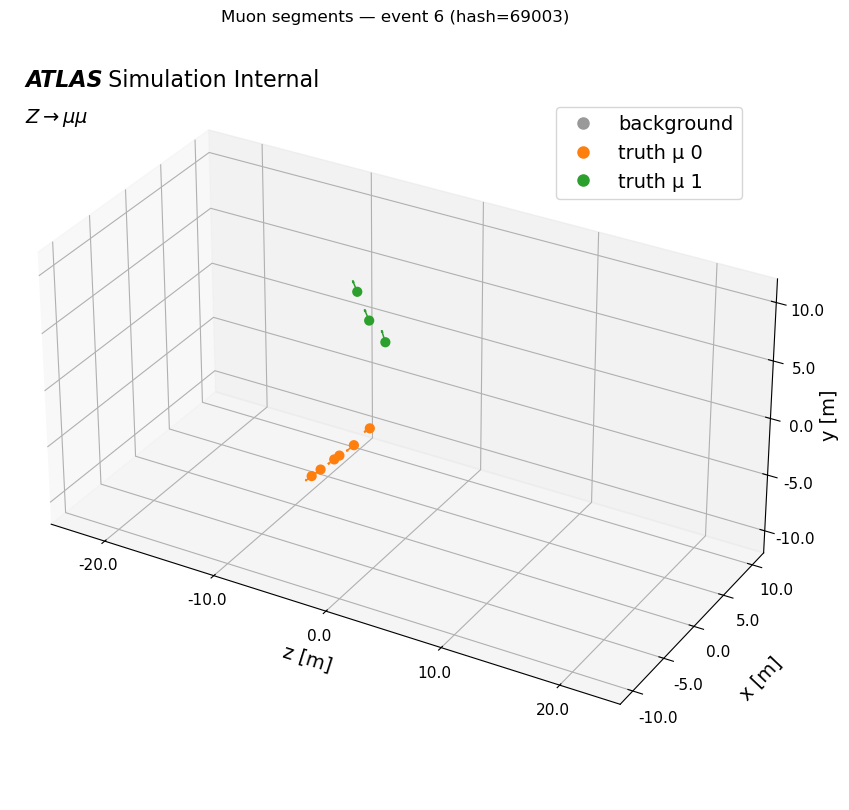

In [14]:
event_number = 6  # first event
pos, dire, evh, has_truth, truth_part = build_segment_event_from_root(input_file, event_number)
plot_segment_event_3d(pos, dire, event_number, evh, has_truth, truth_part, arrow_length_frac=0.02)

In [15]:
def find_event_with_most_truth_parts(
    root_file: str,
    max_events: int = 1000,
    only_with_truth_flag: bool = True,
):
    td, ev_to_idx, uniq = _read_segment_tree(root_file)
    limit = min(max_events, len(uniq))
    if limit == 0:
        raise ValueError("No events found in file.")

    truth_part_all = td["segmentTruthPart"]
    has_truth_all  = td["segmentHasTruth"]

    best = None  # (n_unique_parts, ev_index, ev_hash, n_total, n_truth)

    for ev_i in range(limit):
        evh = int(uniq[ev_i])
        idxs = np.asarray(ev_to_idx[evh], dtype=int)

        if idxs.size == 0:
            continue

        # Collect flattened values for this event
        vals_tparts = []      # one per segment
        truth_flags = []      # bool: has_truth != 0

        for idx in idxs:
            tp_raw = truth_part_all[idx]
            ht_raw = has_truth_all[idx]

            # Flatten has_truth
            ht_flat = np.ravel(ht_raw)
            ht_scalar = int(ht_flat[0]) if ht_flat.size > 0 else 0
            truth_flags.append(ht_scalar != 0)

            # Flatten truth_part, use -1 sentinel if empty
            tp_flat = np.ravel(tp_raw)
            if tp_flat.size > 0:
                tp_scalar = int(tp_flat[0])
            else:
                tp_scalar = -1  # sentinel for "no truth part"
            vals_tparts.append(tp_scalar)

        vals_tparts = np.asarray(vals_tparts, dtype=np.int64)
        truth_flags = np.asarray(truth_flags, dtype=bool)

        n_total = int(vals_tparts.size)
        n_truth = int(truth_flags.sum())

        # Decide which truth parts to use for uniqueness
        if only_with_truth_flag:
            used = truth_flags & (vals_tparts != -1)
        else:
            used = (vals_tparts != -1)

        tparts_used = vals_tparts[used]

        if tparts_used.size == 0:
            n_unique = 0
        else:
            n_unique = int(np.unique(tparts_used).size)

        if best is None:
            best = (n_unique, ev_i, evh, n_total, n_truth)
        else:
            # Primary: maximize n_unique
            # Tie-break 1: more truth nodes
            # Tie-break 2: more total nodes
            # Tie-break 3: smaller event index
            if (
                n_unique > best[0]
                or (
                    n_unique == best[0]
                    and (
                        n_truth > best[4]
                        or (
                            n_truth == best[4]
                            and (
                                n_total > best[3]
                                or (n_total == best[3] and ev_i < best[1])
                            )
                        )
                    )
                )
            ):
                best = (n_unique, ev_i, evh, n_total, n_truth)

    if best is None:
        raise ValueError("No usable events in scanned range.")

    n_unique, ev_index, ev_hash, n_total, n_truth = best
    return {
        "event_index": int(ev_index),
        "event_hash": int(ev_hash),
        "n_total_nodes": int(n_total),
        "n_truth_nodes": int(n_truth),
        "n_unique_truth_parts": int(n_unique),
    }

In [16]:
info = find_event_with_most_truth_parts(input_file, max_events=1000)
print(info)

{'event_index': 810, 'event_hash': 80351, 'n_total_nodes': 20, 'n_truth_nodes': 11, 'n_unique_truth_parts': 4}


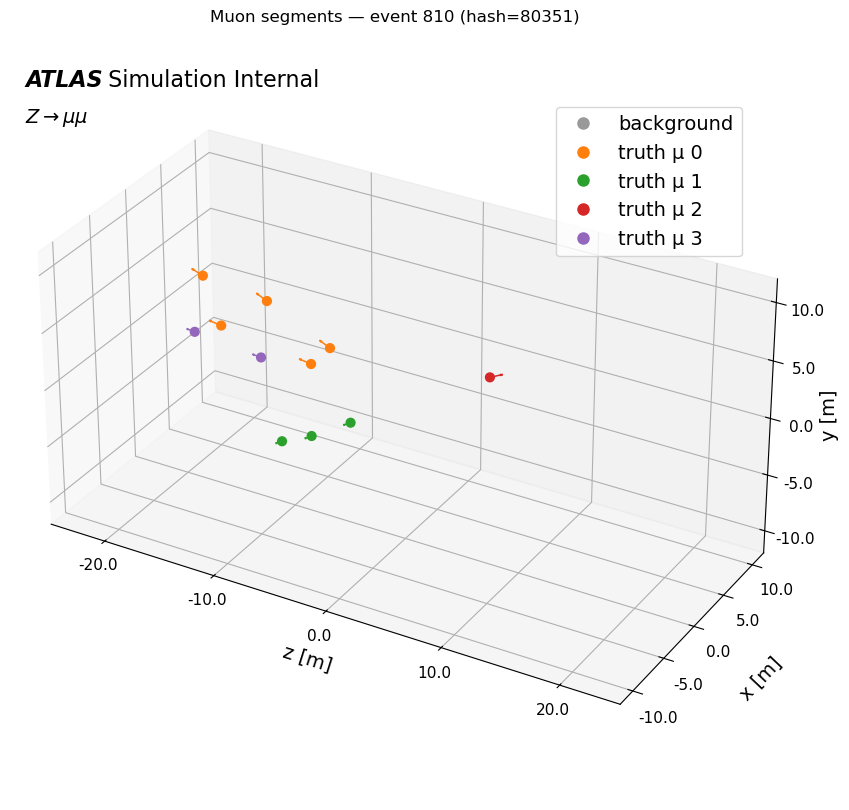

In [17]:
event_number = info["event_index"]
pos, dire, evh, has_truth, truth_part = build_segment_event_from_root(input_file, event_number)
plot_segment_event_3d(pos, dire, event_number, evh, has_truth, truth_part, arrow_length_frac=0.02)

## Building graph connections

In [18]:
def _scalar_from_entry(x):
    """
    Helper: turn entry (possibly small array or scalar) into plain Python scalar.
    """
    a = np.ravel(x)
    if a.size == 0:
        return None
    return a[0]


def build_segment_dataframe(root_file: str) -> pd.DataFrame:
    """
    Build a pandas DataFrame with one row per segment.

    Columns (at least):
        - event_number (0..N_events-1)
        - event_hash
        - seg_index_global (index in the TTree)
        - seg_index_in_event
        - posX, posY, posZ (mm)
        - dirX, dirY, dirZ
        - has_truth
        - truth_part
        - bucket_id            (from bucket_segments)
        - bucket_chamberIndex
        - bucket_layers
        - bucket_sector
    """
    td, ev_to_idx, uniq_hashes = _read_segment_tree(root_file)

    rows = []
    for ev_number, evh in enumerate(uniq_hashes):
        seg_indices = ev_to_idx[int(evh)]
        for j_in_ev, i_global in enumerate(seg_indices):
            # Positions
            px = _scalar_from_entry(td["segmentPositionX"][i_global])
            py = _scalar_from_entry(td["segmentPositionY"][i_global])
            pz = _scalar_from_entry(td["segmentPositionZ"][i_global])

            dx = _scalar_from_entry(td["segmentDirectionX"][i_global])
            dy = _scalar_from_entry(td["segmentDirectionY"][i_global])
            dz = _scalar_from_entry(td["segmentDirectionZ"][i_global])

            if None in (px, py, pz, dx, dy, dz):
                # skip incomplete segments, just like in your existing code
                continue

            has_truth_val = int(np.ravel(td["segmentHasTruth"][i_global])[0])
            if has_truth_val == 0:
                truth_part_val = -1
            else:
                truth_part_val = int(np.ravel(td["segmentTruthPart"][i_global])[0])

            # bucket variables: assumed scalar per segment
            b_id     = _scalar_from_entry(td["bucket_segments"][i_global])
            b_ch     = _scalar_from_entry(td["bucket_chamberIndex"][i_global])
            b_layers = _scalar_from_entry(td["bucket_layers"][i_global])
            b_sector = _scalar_from_entry(td["bucket_sector"][i_global])

            rows.append(
                dict(
                    event_number      = ev_number,
                    event_hash        = int(evh),
                    seg_index_global  = int(i_global),
                    seg_index_in_event= int(j_in_ev),

                    posX_mm = float(px),
                    posY_mm = float(py),
                    posZ_mm = float(pz),

                    dirX = float(dx),
                    dirY = float(dy),
                    dirZ = float(dz),

                    has_truth = has_truth_val,
                    truth_part = truth_part_val,

                    bucket_id            = None if b_id     is None else int(b_id),
                    bucket_chamberIndex  = None if b_ch     is None else int(b_ch),
                    bucket_layers        = None if b_layers is None else int(b_layers),
                    bucket_sector        = None if b_sector is None else int(b_sector),
                )
            )

    df = pd.DataFrame(rows)
    return df


In [19]:
df_segments = build_segment_dataframe(input_file)
print(df_segments.head())

   event_number  event_hash  seg_index_global  seg_index_in_event  \
0             0       69001                 0                   0   
1             0       69001                 1                   1   
2             0       69001                 2                   2   
3             0       69001                 3                   3   
4             0       69001                 6                   6   

       posX_mm      posY_mm      posZ_mm      dirX      dirY      dirZ  \
0 -4021.332520  9708.355469 -1656.597534 -0.301035  0.726763 -0.617409   
1 -3945.193604  9739.893555 -9252.966797 -0.272454  0.672644 -0.687982   
2 -1741.209229  4203.650879 -3720.629883 -0.375217  0.905854 -0.196574   
3 -3016.872559  7537.225098 -6967.860840 -0.272964  0.678651 -0.681853   
4   998.136108   921.615723 -7570.685059  0.011620  0.115841 -0.993200   

   has_truth  truth_part  bucket_id  bucket_chamberIndex  bucket_layers  \
0          0          -1          3                    4         

In [20]:
def sector_distance(s1, s2, n_sectors=16):
    """
    Distance between sectors on a 16-sector ring.

    Data may be labeled 0..31; we fold with mod 16 so that e.g. 15 and 31 map to 15,
    0 and 16 map to 0 (but we keep your special rule 0<->16 => 1).
    """
    if s1 is None or s2 is None:
        return 0  # or np.nan if you prefer

    raw1 = int(s1)
    raw2 = int(s2)

    # special case exactly as requested (in raw labeling space)
    if {raw1, raw2} == {0, 16}:
        return 1

    # fold 0..31 -> 0..15
    s1f = raw1 % n_sectors
    s2f = raw2 % n_sectors

    d = abs(s1f - s2f)
    d = min(d, n_sectors - d)
    return d

In [21]:
def compute_max_bucket_spread(df_segments: pd.DataFrame) -> pd.DataFrame:
    """
    For each (event_number, truth_part), compute the maximum differences
    in bucket variables among segments of the same muon, skipping pairs
    from the same bucket.
    """
    # Keep only segments that have truth info
    df_mu = df_segments[(df_segments["has_truth"] != 0) & (df_segments["truth_part"] >= 0)].copy()

    # Drop rows missing bucket info (if any)
    df_mu = df_mu.dropna(subset=["bucket_id", "bucket_chamberIndex", "bucket_layers", "bucket_sector"])

    def per_muon(group: pd.DataFrame) -> pd.Series:
        b_id     = group["bucket_id"].to_numpy()
        b_ch     = group["bucket_chamberIndex"].to_numpy()
        b_layers = group["bucket_layers"].to_numpy()
        b_sector = group["bucket_sector"].to_numpy()

        n = len(group)
        if n < 2:
            return pd.Series(
                dict(
                    max_d_chamberIndex=0,
                    max_d_layers=0,
                    max_d_sector=0,
                    n_segments=n,
                    n_buckets=len(np.unique(b_id)),
                )
            )

        max_d_ch = 0
        max_d_l  = 0
        max_d_s  = 0

        # naive O(N^2) loop; OK if per-muon N is small-ish
        for i in range(n):
            for j in range(i + 1, n):
                if b_id[i] == b_id[j]:
                    # skip segments from same bucket
                    continue

                d_ch = abs(int(b_ch[i]) - int(b_ch[j]))
                d_l  = abs(int(b_layers[i]) - int(b_layers[j]))
                d_s  = sector_distance(b_sector[i], b_sector[j])

                if d_ch > max_d_ch:
                    max_d_ch = d_ch
                if d_l > max_d_l:
                    max_d_l = d_l
                if d_s > max_d_s:
                    max_d_s = d_s

        return pd.Series(
            dict(
                max_d_chamberIndex=max_d_ch,
                max_d_layers=max_d_l,
                max_d_sector=max_d_s,
                n_segments=n,
                n_buckets=len(np.unique(b_id)),
            )
        )

    result = (
        df_mu
        .groupby(["event_number", "event_hash", "truth_part"])
        .apply(per_muon)
        .reset_index()
    )

    return result


In [22]:
df_segments = build_segment_dataframe(input_file)
df_spread   = compute_max_bucket_spread(df_segments)

print(df_spread.head())

   event_number  event_hash  truth_part  max_d_chamberIndex  max_d_layers  \
0             0       69001           0                   0             0   
1             1       69006           0                   0             0   
2             1       69006           1                   6            10   
3             2       69002           0                   0             0   
4             2       69002           1                   2             7   

   max_d_sector  n_segments  n_buckets  
0             0           2          1  
1             0           4          1  
2             0           4          3  
3             0           3          1  
4             0           3          2  


/tmp/ddicroce/ipykernel_513872/1559842709.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(per_muon)


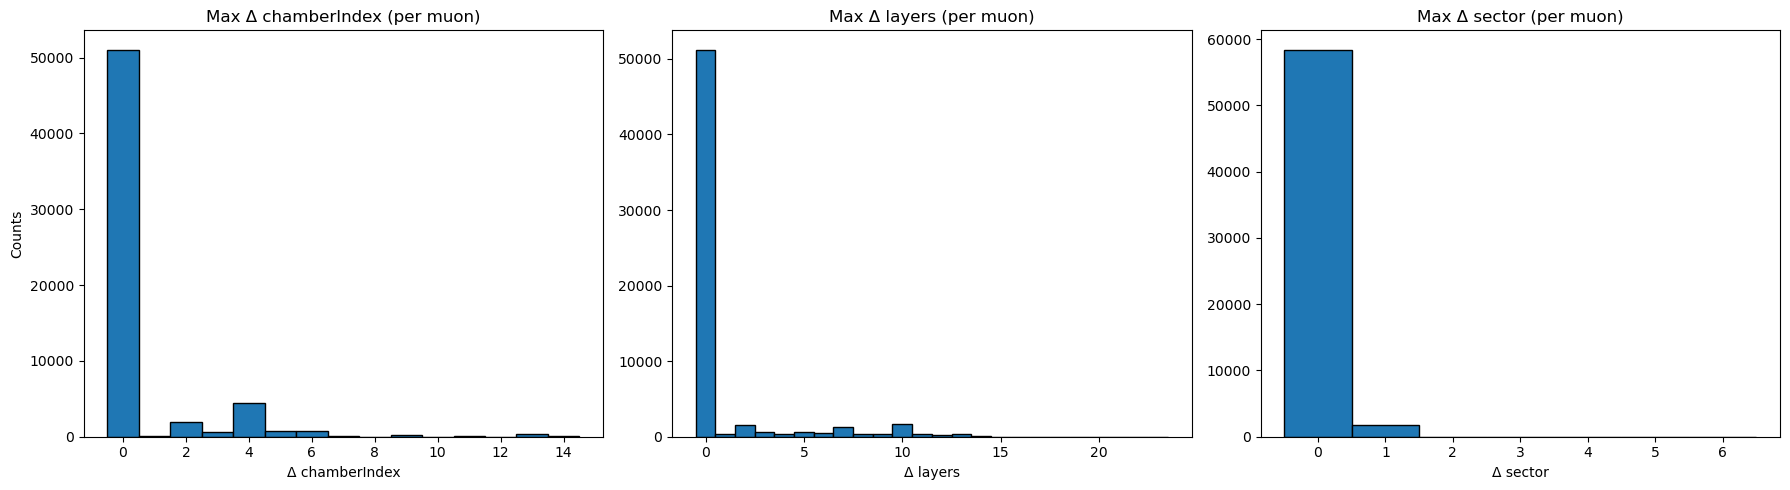

In [23]:
def plot_spread_histograms(df_spread):
    """
    Plot histograms of bucket spread variables:
    - max_d_chamberIndex
    - max_d_layers
    - max_d_sector
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. chamberIndex spread
    ax = axes[0]
    ax.hist(df_spread["max_d_chamberIndex"], bins=np.arange(-0.5, df_spread["max_d_chamberIndex"].max() + 1.5, 1),
            edgecolor="black")
    ax.set_title("Max Δ chamberIndex (per muon)")
    ax.set_xlabel("Δ chamberIndex")
    ax.set_ylabel("Counts")

    # 2. layers spread
    ax = axes[1]
    ax.hist(df_spread["max_d_layers"], bins=np.arange(-0.5, df_spread["max_d_layers"].max() + 1.5, 1),
            edgecolor="black")
    ax.set_title("Max Δ layers (per muon)")
    ax.set_xlabel("Δ layers")

    # 3. sector spread (with wrap-around rule)
    ax = axes[2]
    ax.hist(df_spread["max_d_sector"], bins=np.arange(-0.5, df_spread["max_d_sector"].max() + 1.5, 1),
            edgecolor="black")
    ax.set_title("Max Δ sector (per muon)")
    ax.set_xlabel("Δ sector")

    plt.tight_layout()
    plt.show()


# Call it
plot_spread_histograms(df_spread)

In [24]:
def compute_intra_muon_distances(
    df_segments: pd.DataFrame,
    skip_same_bucket: bool = False,
    max_pairs_per_muon: int | None = None,   # optional cap to avoid huge O(N^2)
) -> pd.DataFrame:
    """
    Build a table of distances between segments belonging to the SAME muon
    (same event_number, event_hash, truth_part).

    Returns one row per segment-pair with:
      - dr_xy_mm, dR_xyz_mm
      - plus metadata (event, muon id, indices, buckets)
    """
    df_mu = df_segments[(df_segments["has_truth"] != 0) & (df_segments["truth_part"] >= 0)].copy()

    # Ensure we have positions
    df_mu = df_mu.dropna(subset=["posX_mm", "posY_mm", "posZ_mm"])

    if skip_same_bucket:
        df_mu = df_mu.dropna(subset=["bucket_id"])

    rows = []

    for (evn, evh, tp), g in df_mu.groupby(["event_number", "event_hash", "truth_part"]):
        n = len(g)
        if n < 2:
            continue

        x = g["posX_mm"].to_numpy(float)
        y = g["posY_mm"].to_numpy(float)
        z = g["posZ_mm"].to_numpy(float)

        if skip_same_bucket:
            b = g["bucket_id"].to_numpy()

        # all pairs i<j
        pair_count = 0
        for i in range(n):
            for j in range(i + 1, n):
                if skip_same_bucket and b[i] == b[j]:
                    continue

                dx = x[j] - x[i]
                dy = y[j] - y[i]
                dz = z[j] - z[i]

                dr_xy = np.sqrt(dx*dx + dy*dy)
                dR    = np.sqrt(dx*dx + dy*dy + dz*dz)

                rows.append(dict(
                    event_number=int(evn),
                    event_hash=int(evh),
                    truth_part=int(tp),
                    i=int(g.iloc[i]["seg_index_global"]),
                    j=int(g.iloc[j]["seg_index_global"]),
                    dr_xy_mm=float(dr_xy),
                    dR_xyz_mm=float(dR),
                    bucket_i=None if not skip_same_bucket else int(b[i]),
                    bucket_j=None if not skip_same_bucket else int(b[j]),
                ))

                pair_count += 1
                if max_pairs_per_muon is not None and pair_count >= max_pairs_per_muon:
                    break
            if max_pairs_per_muon is not None and pair_count >= max_pairs_per_muon:
                break

    return pd.DataFrame(rows)


def compute_intra_muon_max_distances(df_pairs: pd.DataFrame) -> pd.DataFrame:
    """
    Reduce pairwise distances to one number per muon: max(dr_xy), max(dR_xyz).
    """
    if df_pairs.empty:
        return df_pairs

    return (
        df_pairs
        .groupby(["event_number", "event_hash", "truth_part"], as_index=False)
        .agg(
            max_dr_xy_mm=("dr_xy_mm", "max"),
            max_dR_xyz_mm=("dR_xyz_mm", "max"),
            n_pairs=("dr_xy_mm", "size"),
        )
    )

In [25]:
def plot_intra_muon_pair_hists(df_pairs: pd.DataFrame, bins=80):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df_pairs["dr_xy_mm"], bins=bins, edgecolor="black")
    axes[0].set_title("Intra-muon segment-pair distance: r(x,y)")
    axes[0].set_xlabel("dr_xy [mm]")
    axes[0].set_ylabel("Counts")

    axes[1].hist(df_pairs["dR_xyz_mm"], bins=bins, edgecolor="black")
    axes[1].set_title("Intra-muon segment-pair distance: R(x,y,z)")
    axes[1].set_xlabel("dR_xyz [mm]")
    axes[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()

   event_number  event_hash  truth_part   i   j     dr_xy_mm     dR_xyz_mm  \
0             1       69006           1  10  11  3992.868996   8190.828093   
1             1       69006           1  10  13  5293.641602  11404.527154   
2             1       69006           1  10  14  7464.120117  15736.656566   
3             1       69006           1  11  14  3967.582654   7788.499328   
4             1       69006           1  13  14  2170.478516   4334.861892   

   bucket_i  bucket_j  
0         4         1  
1         4         1  
2         4         2  
3         1         2  
4         1         2  


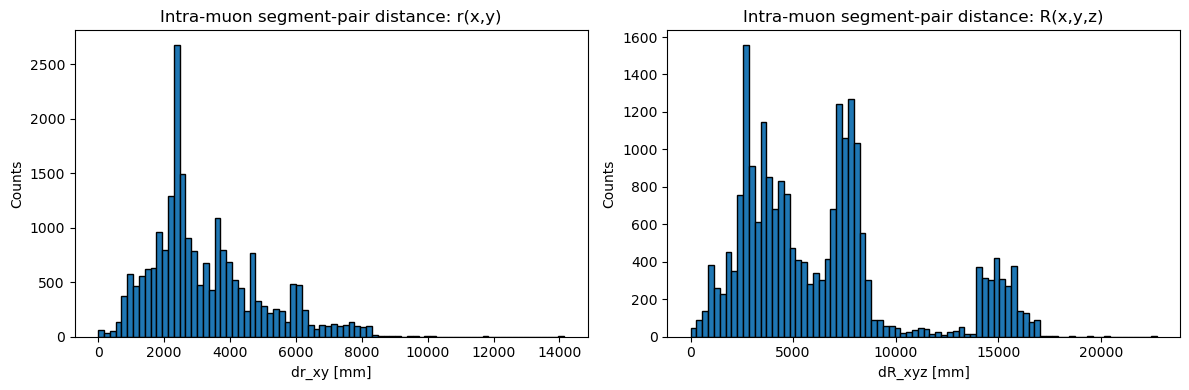

In [26]:
df_pairs = compute_intra_muon_distances(
    df_segments,
    skip_same_bucket=True,      # set False if you want all pairs
    max_pairs_per_muon=None,    # or set e.g. 200 to cap
)

print(df_pairs.head())
plot_intra_muon_pair_hists(df_pairs)

In [27]:
def plot_intra_muon_max_hists(df_max: pd.DataFrame, bins=60):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df_max["max_dr_xy_mm"], bins=bins, edgecolor="black")
    axes[0].set_title("Per-muon max spread: max r(x,y)")
    axes[0].set_xlabel("max dr_xy [mm]")
    axes[0].set_ylabel("Muons")

    axes[1].hist(df_max["max_dR_xyz_mm"], bins=bins, edgecolor="black")
    axes[1].set_title("Per-muon max spread: max R(x,y,z)")
    axes[1].set_xlabel("max dR_xyz [mm]")
    axes[1].set_ylabel("Muons")

    plt.tight_layout()
    plt.show()

   event_number  event_hash  truth_part  max_dr_xy_mm  max_dR_xyz_mm  n_pairs
0             1       69006           1   7464.120117   15736.656566        5
1             2       69002           1   2772.360329    7670.244053        2
2             4       69009           0   7275.152738   15647.910983        2
3            12       69020           0   6407.777507   15263.973380        2
4            13       69012           0   3877.406925    7742.951254        1


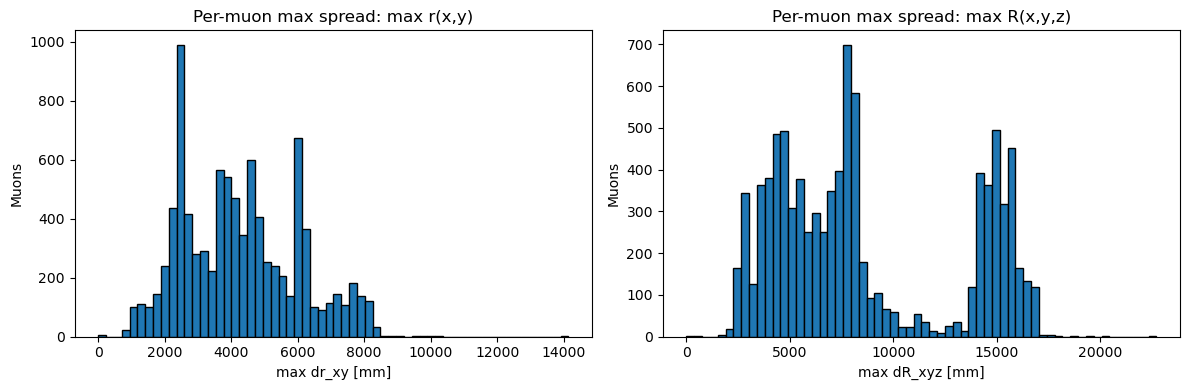

In [28]:

df_max = compute_intra_muon_max_distances(df_pairs)
print(df_max.head())
plot_intra_muon_max_hists(df_max)

In [29]:
def _theta_phi_from_dir(dx, dy, dz):
    """
    dx,dy,dz arrays -> theta, phi arrays (radians)
    theta in [0, pi], phi in (-pi, pi]
    """
    dx = np.asarray(dx, float)
    dy = np.asarray(dy, float)
    dz = np.asarray(dz, float)

    norm = np.sqrt(dx*dx + dy*dy + dz*dz)
    norm = np.where(norm == 0, 1.0, norm)

    cos_theta = np.clip(dz / norm, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    phi = np.arctan2(dy, dx)
    return theta, phi


def _delta_phi(phi1, phi2):
    """
    Smallest absolute wrapped delta phi in [0, pi].
    """
    d = phi2 - phi1
    d = (d + np.pi) % (2*np.pi) - np.pi  # wrap to [-pi, pi]
    return np.abs(d)


def compute_intra_muon_angle_differences(
    df_segments: pd.DataFrame,
    skip_same_bucket: bool = False,
    max_pairs_per_muon: int | None = None,
    degrees: bool = True,
) -> pd.DataFrame:
    """
    Pairwise angular differences between segments of the SAME muon
    (same event_number, event_hash, truth_part).

    Returns one row per segment-pair with:
      - dtheta, dphi (deg by default; rad if degrees=False)
    """
    df_mu = df_segments[(df_segments["has_truth"] != 0) & (df_segments["truth_part"] >= 0)].copy()

    # Need directions
    df_mu = df_mu.dropna(subset=["dirX", "dirY", "dirZ"])

    if skip_same_bucket:
        df_mu = df_mu.dropna(subset=["bucket_id"])

    rows = []
    conv = 180.0 / np.pi if degrees else 1.0

    for (evn, evh, tp), g in df_mu.groupby(["event_number", "event_hash", "truth_part"]):
        n = len(g)
        if n < 2:
            continue

        dx = g["dirX"].to_numpy(float)
        dy = g["dirY"].to_numpy(float)
        dz = g["dirZ"].to_numpy(float)
        theta, phi = _theta_phi_from_dir(dx, dy, dz)

        if skip_same_bucket:
            b = g["bucket_id"].to_numpy()

        pair_count = 0
        for i in range(n):
            for j in range(i + 1, n):
                if skip_same_bucket and b[i] == b[j]:
                    continue

                dtheta = abs(theta[j] - theta[i]) * conv
                dphi   = _delta_phi(phi[i], phi[j]) * conv

                rows.append(dict(
                    event_number=int(evn),
                    event_hash=int(evh),
                    truth_part=int(tp),
                    i=int(g.iloc[i]["seg_index_global"]),
                    j=int(g.iloc[j]["seg_index_global"]),
                    dtheta=float(dtheta),
                    dphi=float(dphi),
                    bucket_i=None if not skip_same_bucket else int(b[i]),
                    bucket_j=None if not skip_same_bucket else int(b[j]),
                ))

                pair_count += 1
                if max_pairs_per_muon is not None and pair_count >= max_pairs_per_muon:
                    break
            if max_pairs_per_muon is not None and pair_count >= max_pairs_per_muon:
                break

    return pd.DataFrame(rows)


def compute_intra_muon_max_angle_differences(df_pairs_ang: pd.DataFrame) -> pd.DataFrame:
    """
    Reduce pairwise angle differences to one number per muon: max(dtheta), max(dphi).
    """
    if df_pairs_ang.empty:
        return df_pairs_ang

    return (
        df_pairs_ang
        .groupby(["event_number", "event_hash", "truth_part"], as_index=False)
        .agg(
            max_dtheta=("dtheta", "max"),
            max_dphi=("dphi", "max"),
            n_pairs=("dtheta", "size"),
        )
    )


def plot_intra_muon_angle_hists(df_pairs_ang: pd.DataFrame, degrees: bool = True, bins=80):
    unit = "deg" if degrees else "rad"
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df_pairs_ang["dtheta"], bins=bins, edgecolor="black")
    axes[0].set_title("Intra-muon segment-pair Δθ")
    axes[0].set_xlabel(f"Δθ [{unit}]")
    axes[0].set_ylabel("Counts")

    axes[1].hist(df_pairs_ang["dphi"], bins=bins, edgecolor="black")
    axes[1].set_title("Intra-muon segment-pair Δφ (wrapped)")
    axes[1].set_xlabel(f"Δφ [{unit}]")
    axes[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()


def plot_intra_muon_max_angle_hists(df_max_ang: pd.DataFrame, degrees: bool = True, bins=60):
    unit = "deg" if degrees else "rad"
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df_max_ang["max_dtheta"], bins=bins, edgecolor="black")
    axes[0].set_title("Per-muon max Δθ")
    axes[0].set_xlabel(f"max Δθ [{unit}]")
    axes[0].set_ylabel("Muons")

    axes[1].hist(df_max_ang["max_dphi"], bins=bins, edgecolor="black")
    axes[1].set_title("Per-muon max Δφ (wrapped)")
    axes[1].set_xlabel(f"max Δφ [{unit}]")
    axes[1].set_ylabel("Muons")

    plt.tight_layout()
    plt.show()

   event_number  event_hash  truth_part   i   j    dtheta       dphi  \
0             1       69006           1  10  11  0.469275  13.246163   
1             1       69006           1  10  13  0.669306   0.000000   
2             1       69006           1  10  14  3.927471   0.000000   
3             1       69006           1  11  14  3.458197  13.246163   
4             1       69006           1  13  14  3.258165   0.000000   

   bucket_i  bucket_j  
0         4         1  
1         4         1  
2         4         2  
3         1         2  
4         1         2  


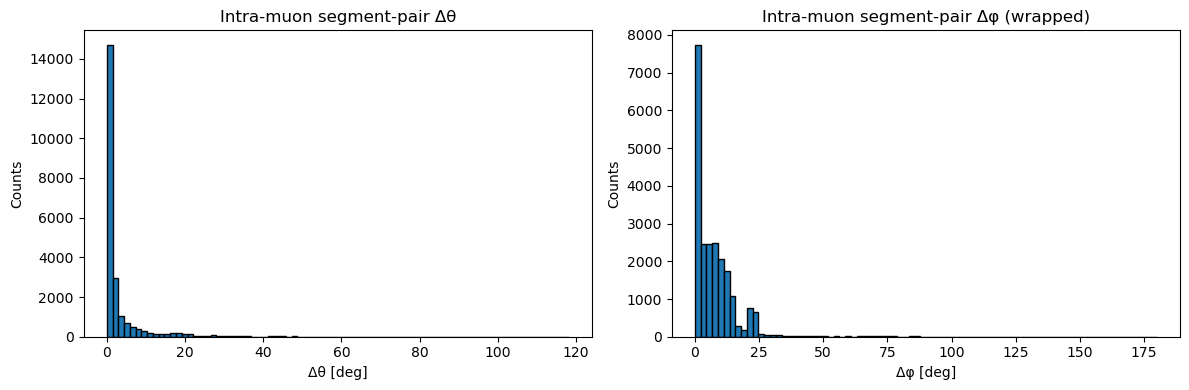

   event_number  event_hash  truth_part  max_dtheta   max_dphi  n_pairs
0             1       69006           1    3.927471  13.246163        5
1             2       69002           1    1.130425  10.794252        2
2             4       69009           0    0.155119   2.698420        2
3            12       69020           0    0.990100   4.719003        2
4            13       69012           0    0.481873  12.973493        1


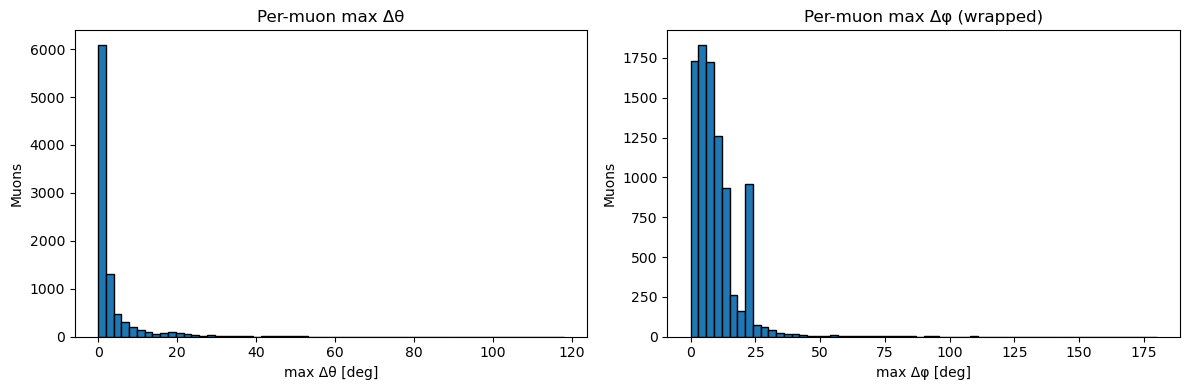

In [30]:
df_pairs_ang = compute_intra_muon_angle_differences(
    df_segments,
    skip_same_bucket=True,     # match your earlier “skip same bucket” logic
    max_pairs_per_muon=None,
    degrees=True,              # set False for radians
)

print(df_pairs_ang.head())
plot_intra_muon_angle_hists(df_pairs_ang, degrees=True)

df_max_ang = compute_intra_muon_max_angle_differences(df_pairs_ang)
print(df_max_ang.head())
plot_intra_muon_max_angle_hists(df_max_ang, degrees=True)